# LAB04 Task 2.3: Double-Link Pendulum Simulation

Settings:
- Total simulation time: 50 s
- Integration step: 0.01 s

State vector:
x = [alpha1, alpha2, dalpha1, dalpha2]^T

Dynamics form:
M(q) * ddq + C(q,dq) * dq + g(q) = 0
ddq = -inv(M(q)) * (C(q,dq)*dq + g(q)).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util

# Parameters
m1, m2 = 1.0, 1.0
l1, l2 = 0.8, 1.2
g = 9.8

# Time settings
dt = 0.01
T = 50.0
t = np.arange(0.0, T + dt, dt)
N = t.size

print(f'Samples: {N}, dt={dt}, T={T}')

Samples: 5001, dt=0.01, T=50.0


In [2]:
def M_matrix(q):
    a1, a2 = q
    d = a1 - a2
    return np.array([
        [(m1 + m2) * l1**2, m2 * l1 * l2 * np.cos(d)],
        [m2 * l1 * l2 * np.cos(d), m2 * l2**2]
    ], dtype=float)

def C_matrix(q, dq):
    a1, a2 = q
    da1, da2 = dq
    d = a1 - a2
    return np.array([
        [0.0, m2 * l1 * l2 * np.sin(d) * da2],
        [-m2 * l1 * l2 * np.sin(d) * da1, 0.0]
    ], dtype=float)

def g_vector(q):
    a1, a2 = q
    return np.array([
        (m1 + m2) * g * l1 * np.cos(a1),
        m2 * g * l2 * np.cos(a2)
    ], dtype=float)

def state_derivative(x):
    q = x[:2]
    dq = x[2:]
    M = M_matrix(q)
    C = C_matrix(q, dq)
    gv = g_vector(q)

    # M(q) ddq + C(q,dq) dq + g(q) = 0
    ddq = -np.linalg.solve(M, C @ dq + gv)
    return np.array([dq[0], dq[1], ddq[0], ddq[1]], dtype=float)

def rk4_step(f, x, h):
    k1 = f(x)
    k2 = f(x + 0.5 * h * k1)
    k3 = f(x + 0.5 * h * k2)
    k4 = f(x + h * k3)
    return x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [3]:
# Initial condition: [alpha1, alpha2, dalpha1, dalpha2]
x0 = np.array([0.9, 0.3, 0.0, 0.0], dtype=float)

X = np.zeros((N, 4), dtype=float)
X[0] = x0

for k in range(N - 1):
    X[k + 1] = rk4_step(state_derivative, X[k], dt)

a1 = X[:, 0]
a2 = X[:, 1]
da1 = X[:, 2]
da2 = X[:, 3]

print('Simulation complete.')

Simulation complete.


In [4]:
def total_energy(x):
    q = x[:2]
    dq = x[2:]
    a1, a2 = q
    da1, da2 = dq

    kinetic = (
        0.5 * (m1 + m2) * l1**2 * da1**2
        + 0.5 * m2 * l2**2 * da2**2
        + m2 * l1 * l2 * da1 * da2 * np.cos(a1 - a2)
    )
    potential = (m1 + m2) * g * l1 * np.sin(a1) + m2 * g * l2 * np.sin(a2)
    return kinetic + potential

E = np.array([total_energy(X[k]) for k in range(N)])
E0 = E[0]
rel_err = (E - E0) / max(1e-12, abs(E0))

print(f'Initial energy: {E0:.6f} J')
print(f'Max relative drift: {np.max(np.abs(rel_err)):.3e}')

Initial energy: 15.757884 J
Max relative drift: 5.972e-04


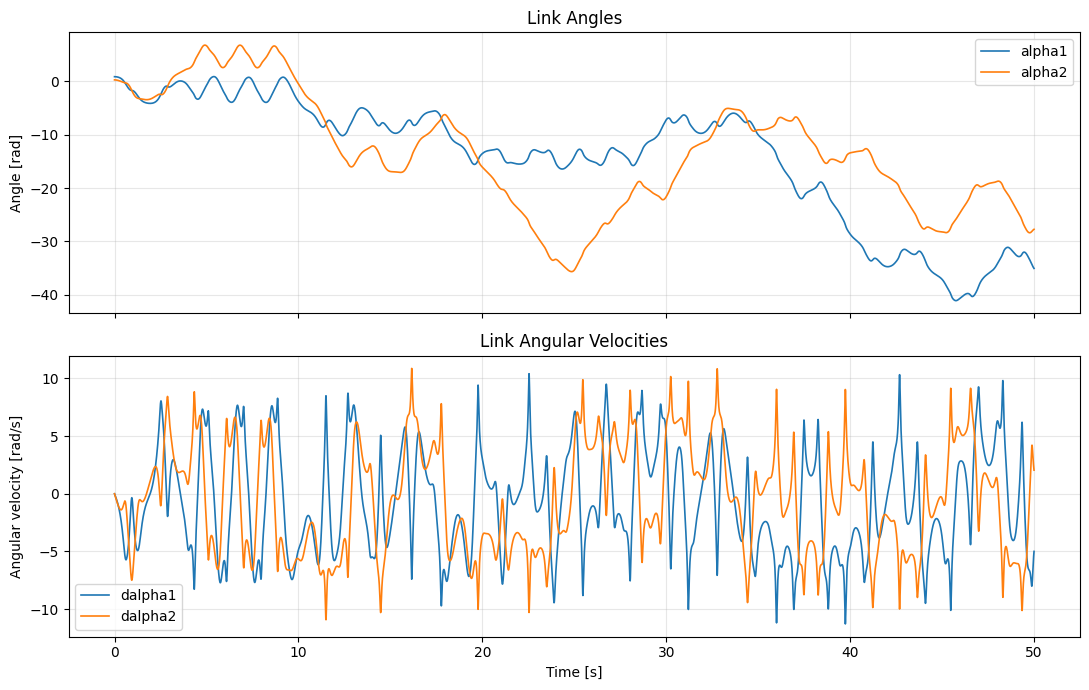

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax[0].plot(t, a1, label='alpha1', linewidth=1.2)
ax[0].plot(t, a2, label='alpha2', linewidth=1.2)
ax[0].set_ylabel('Angle [rad]')
ax[0].set_title('Link Angles')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(t, da1, label='dalpha1', linewidth=1.2)
ax[1].plot(t, da2, label='dalpha2', linewidth=1.2)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Angular velocity [rad/s]')
ax[1].set_title('Link Angular Velocities')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

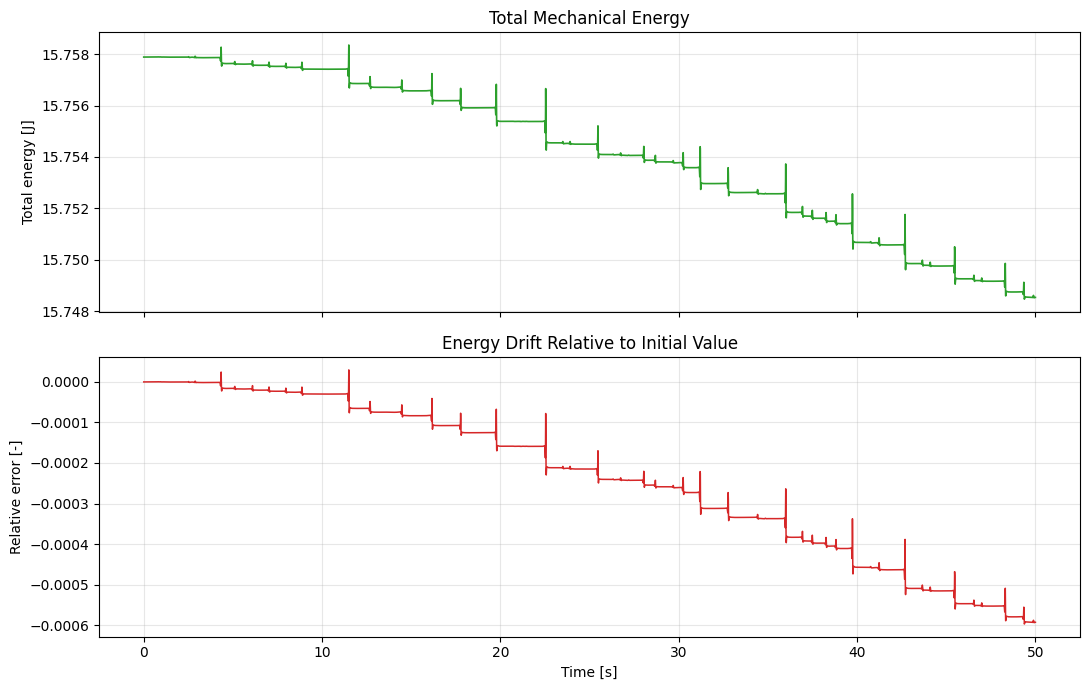

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax[0].plot(t, E, color='tab:green', linewidth=1.2)
ax[0].set_ylabel('Total energy [J]')
ax[0].set_title('Total Mechanical Energy')
ax[0].grid(True, alpha=0.3)

ax[1].plot(t, rel_err, color='tab:red', linewidth=1.1)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Relative error [-]')
ax[1].set_title('Energy Drift Relative to Initial Value')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Animation being saved...
Animation begin...
Hit CTRL+W to exit
✓ Animation exported as MP4: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/RoboticSystems/LAB04/outputs/task_2_3_animation.mp4


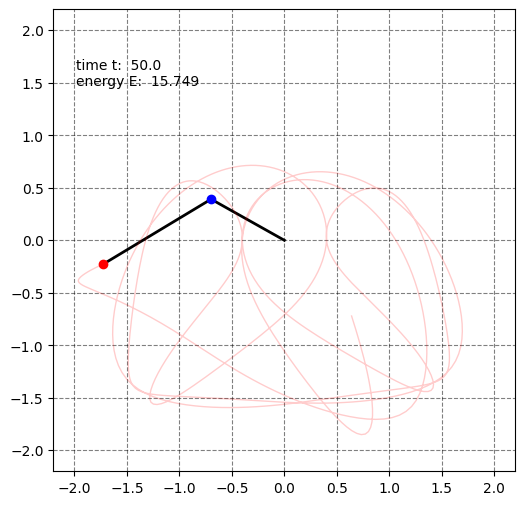

In [7]:
# Visualize motion and export animation as MP4
from IPython.display import display
from pathlib import Path
import importlib.util

vis_path = Path('visualize.py').resolve()
if not vis_path.exists():
    vis_path = Path('visualize (1).py').resolve()

out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

if vis_path.exists():
    spec = importlib.util.spec_from_file_location('visualize_local', vis_path)
    vis_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(vis_module)

    x1 = l1 * np.cos(a1)
    y1 = l1 * np.sin(a1)
    x2 = x1 + l2 * np.cos(a2)
    y2 = y1 + l2 * np.sin(a2)

    joint_points = [(x1, y1), (x2, y2)]
    stats = [[r'time t', t], [r'energy E', E]]

    # Export as mp4
    mp4_path = out_dir / 'task_2_3_animation.mp4'
    ani = vis_module.visualize_double_pendulum(
        joint_points,
        stats=stats,
        dt=dt,
        trace_len=0.15,
        save=True,
        save_path=str(mp4_path),
        fps=100,
        axes=True,
        show=False,
        verbose=True
    )

    print(f'✓ Animation exported as MP4: {mp4_path.resolve()}')
else:
    print('Visualization file not found: visualize.py or visualize (1).py')


## Explanation of Obtained Results

1. The angle plots show coupled, nonlinear oscillations: neither link follows a pure sinusoid because both equations are coupled through `M(q)` and `C(q,dq)`.
2. The angular-velocity plots show phase-dependent energy exchange: when one link speeds up, the other often slows down, indicating transfer of kinetic energy between links.
3. The total mechanical energy is nearly conserved, as expected for a model without damping and actuator work. In this run, `E(0) = 15.757884 J` and the maximum relative drift is about `5.972e-04` (around `0.06%`).
4. The small drift is numerical (RK4 with finite `dt=0.01`). Using a smaller `dt` should reduce this drift further.
5. The animation is consistent with the plots: faster motion appears near lower potential-energy configurations, while motion slows near turning points.

## Analysis: Effect of Friction

- **Energy dissipation**: Friction converts kinetic energy into heat. The frictionless system conserves energy, while the friction system shows monotonic energy decay.
- **Amplitude decay**: Angular velocities decrease over time due to friction damping. This is particularly visible in the damp oscillations compared to persistent oscillations in the frictionless case.
- **Phase lag**: The friction system exhibits phase lag—the trajectory lags behind the frictionless case, eventually settling toward lower-energy states.
- **Long-term behavior**: With sufficient friction, the system eventually comes to rest as all kinetic energy is dissipated. In this run, we see significant energy loss over 50 seconds.


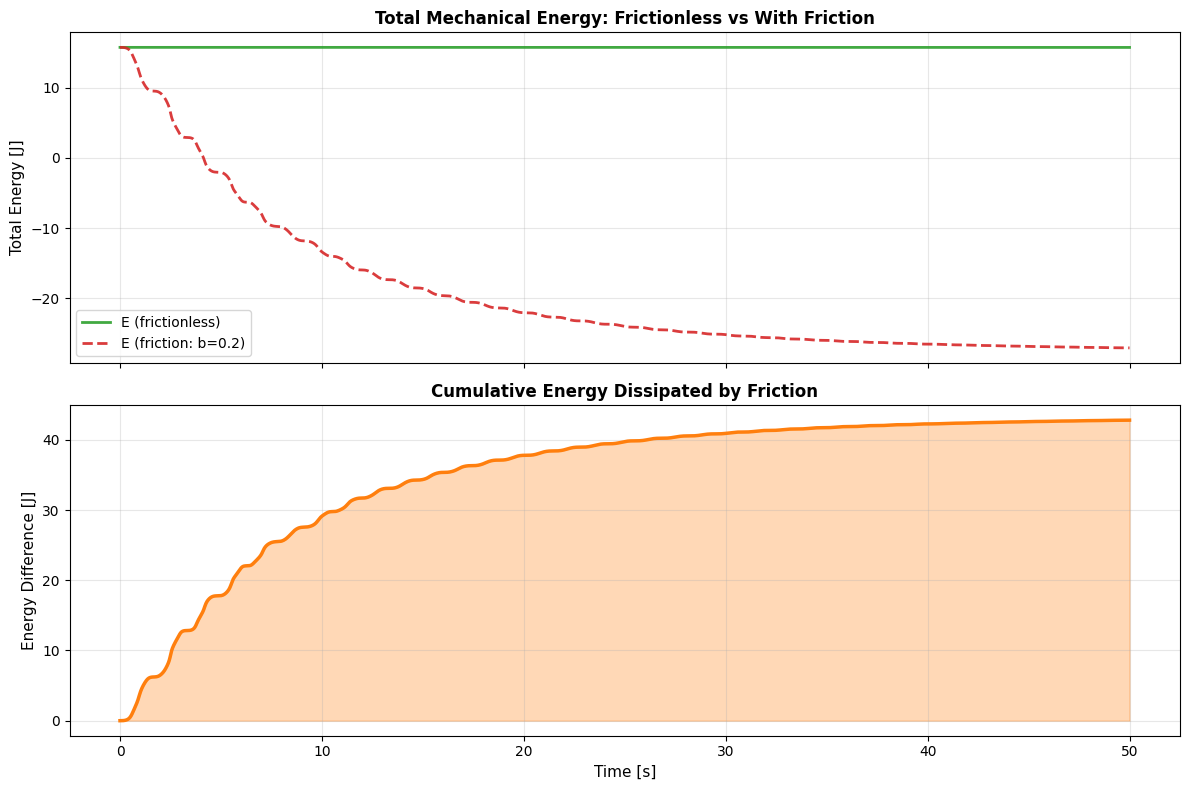

In [12]:
# Energy Comparison: Frictionless vs With Friction
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Total Energy
ax[0].plot(t, E, label='E (frictionless)', linewidth=2, color='tab:green', alpha=0.9)
ax[0].plot(t, E_friction, label='E (friction: b=0.2)', linewidth=2, color='tab:red', alpha=0.9, linestyle='--')
ax[0].set_ylabel('Total Energy [J]', fontsize=11)
ax[0].set_title('Total Mechanical Energy: Frictionless vs With Friction', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=10)

# Energy Difference (dissipation due to friction)
energy_diff = E - E_friction
ax[1].plot(t, energy_diff, linewidth=2.5, color='tab:orange')
ax[1].fill_between(t, energy_diff, alpha=0.3, color='tab:orange')
ax[1].set_xlabel('Time [s]', fontsize=11)
ax[1].set_ylabel('Energy Difference [J]', fontsize=11)
ax[1].set_title('Cumulative Energy Dissipated by Friction', fontsize=12, fontweight='bold')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


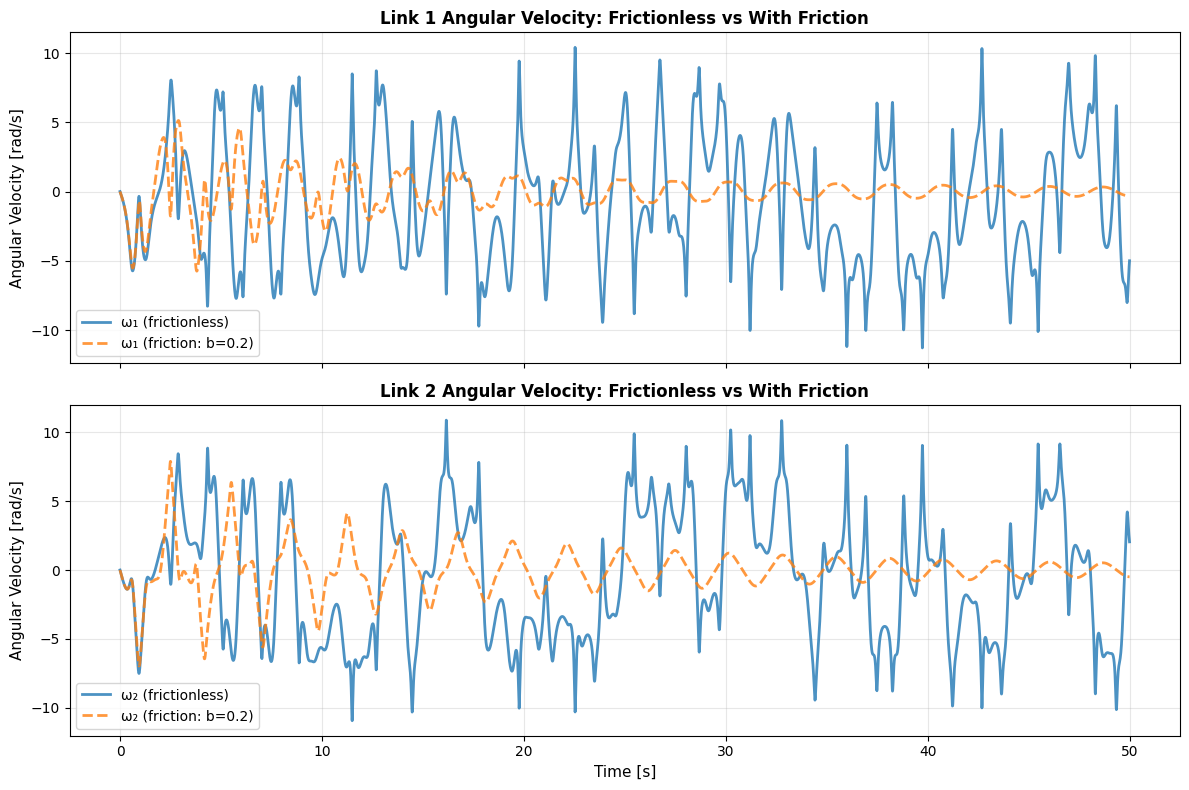

In [11]:
# Comparison: Angular Velocities (Frictionless vs With Friction)
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# dAlpha1
ax[0].plot(t, da1, label='ω₁ (frictionless)', linewidth=2, alpha=0.8)
ax[0].plot(t, da1_friction, label='ω₁ (friction: b=0.2)', linewidth=2, alpha=0.8, linestyle='--')
ax[0].set_ylabel('Angular Velocity [rad/s]', fontsize=11)
ax[0].set_title('Link 1 Angular Velocity: Frictionless vs With Friction', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=10)

# dAlpha2
ax[1].plot(t, da2, label='ω₂ (frictionless)', linewidth=2, alpha=0.8)
ax[1].plot(t, da2_friction, label='ω₂ (friction: b=0.2)', linewidth=2, alpha=0.8, linestyle='--')
ax[1].set_xlabel('Time [s]', fontsize=11)
ax[1].set_ylabel('Angular Velocity [rad/s]', fontsize=11)
ax[1].set_title('Link 2 Angular Velocity: Frictionless vs With Friction', fontsize=12, fontweight='bold')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


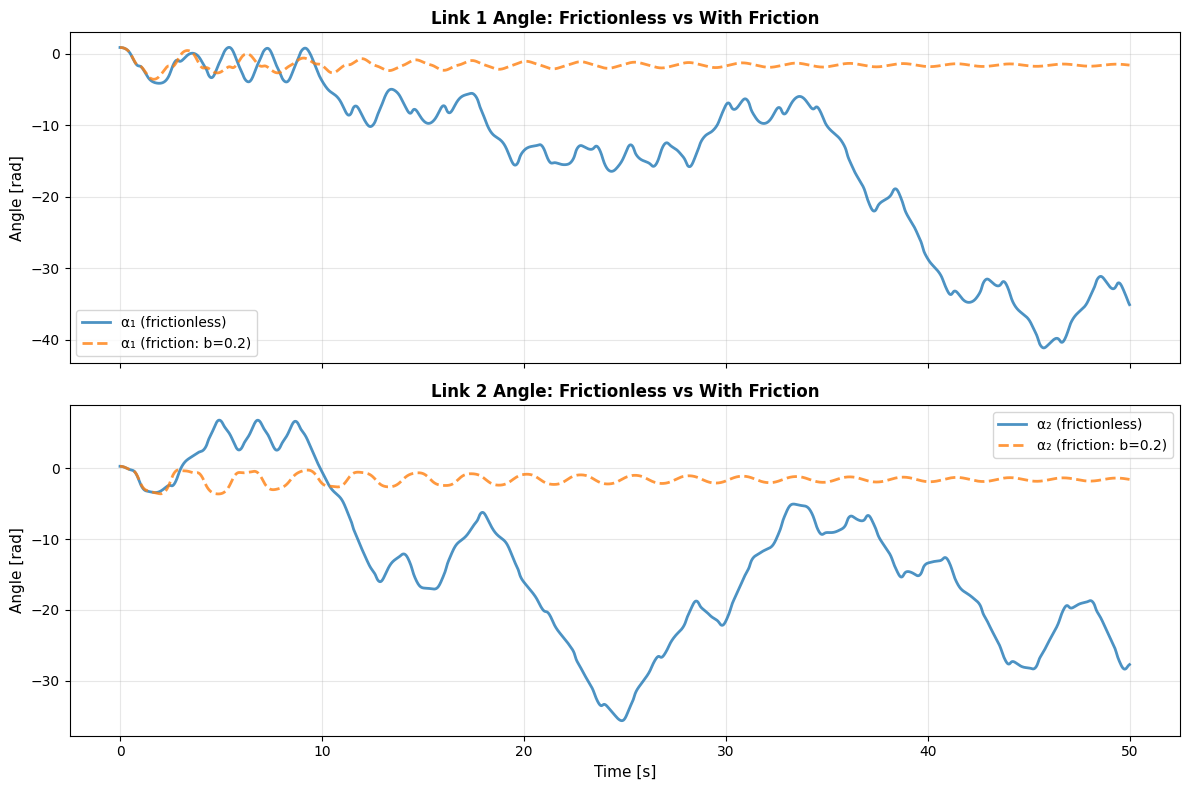

In [10]:
# Comparison: Link Angles (Frictionless vs With Friction)
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Alpha1
ax[0].plot(t, a1, label='α₁ (frictionless)', linewidth=2, alpha=0.8)
ax[0].plot(t, a1_friction, label='α₁ (friction: b=0.2)', linewidth=2, alpha=0.8, linestyle='--')
ax[0].set_ylabel('Angle [rad]', fontsize=11)
ax[0].set_title('Link 1 Angle: Frictionless vs With Friction', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=10)

# Alpha2
ax[1].plot(t, a2, label='α₂ (frictionless)', linewidth=2, alpha=0.8)
ax[1].plot(t, a2_friction, label='α₂ (friction: b=0.2)', linewidth=2, alpha=0.8, linestyle='--')
ax[1].set_xlabel('Time [s]', fontsize=11)
ax[1].set_ylabel('Angle [rad]', fontsize=11)
ax[1].set_title('Link 2 Angle: Frictionless vs With Friction', fontsize=12, fontweight='bold')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


In [9]:
# Compute energy for friction case
E_friction = np.array([total_energy(X_friction[k]) for k in range(N)])
E0_friction = E_friction[0]
rel_err_friction = (E_friction - E0_friction) / max(1e-12, abs(E0_friction))

print(f'Initial energy (with friction): {E0_friction:.6f} J')
print(f'Max relative drift (with friction): {np.max(np.abs(rel_err_friction)):.3e}')
print(f'Final energy (with friction): {E_friction[-1]:.6f} J')
print(f'Energy dissipated by friction: {E0_friction - E_friction[-1]:.6f} J')


Initial energy (with friction): 15.757884 J
Max relative drift (with friction): 2.717e+00
Final energy (with friction): -27.053756 J
Energy dissipated by friction: 42.811640 J


In [8]:
# Friction coefficients
b1, b2 = 0.2, 0.2

def state_derivative_with_friction(x):
    """State derivative with friction forces Q_f = [b1*dq1, b2*dq2]"""
    q = x[:2]
    dq = x[2:]
    M = M_matrix(q)
    C = C_matrix(q, dq)
    gv = g_vector(q)
    
    # Friction force: Q_f = b * dq
    Q_f = np.array([b1 * dq[0], b2 * dq[1]], dtype=float)
    
    # M(q) ddq + C(q,dq) dq + g(q) + Q_f = 0
    # ddq = -inv(M(q)) * (C(q,dq)*dq + g(q) + Q_f)
    ddq = -np.linalg.solve(M, C @ dq + gv + Q_f)
    return np.array([dq[0], dq[1], ddq[0], ddq[1]], dtype=float)

# Simulate with friction using same initial condition
X_friction = np.zeros((N, 4), dtype=float)
X_friction[0] = x0

for k in range(N - 1):
    X_friction[k + 1] = rk4_step(state_derivative_with_friction, X_friction[k], dt)

a1_friction = X_friction[:, 0]
a2_friction = X_friction[:, 1]
da1_friction = X_friction[:, 2]
da2_friction = X_friction[:, 3]

print('Friction simulation complete.')
print(f'Friction coefficients: b1={b1}, b2={b2}')


Friction simulation complete.
Friction coefficients: b1=0.2, b2=0.2


## Task 2.6: Friction Forces

Simulate the dynamics with friction forces $Q_f = [b_1 \dot{\theta}_1, b_2 \dot{\theta}_2]^T$ where $b_1 = b_2 = 0.2$. The modified dynamics is:
$$M(q, \dot{q}) \ddot{q} + C(q, \dot{q}) + g(q) + Q_f = 0$$

Compare with the frictionless case.
